🗄️ Inspecting DataStore 'fx.min' Matrices...

✅ Data Matrix Assembled Successfully!
   Total Time Steps: 94,440
   Date Range:       2023-10-01 19:00:00  -->  2023-12-31 22:00:00
   C:AUDUSD valid ticks: 94,440
   C:NZDUSD valid ticks: 94,440


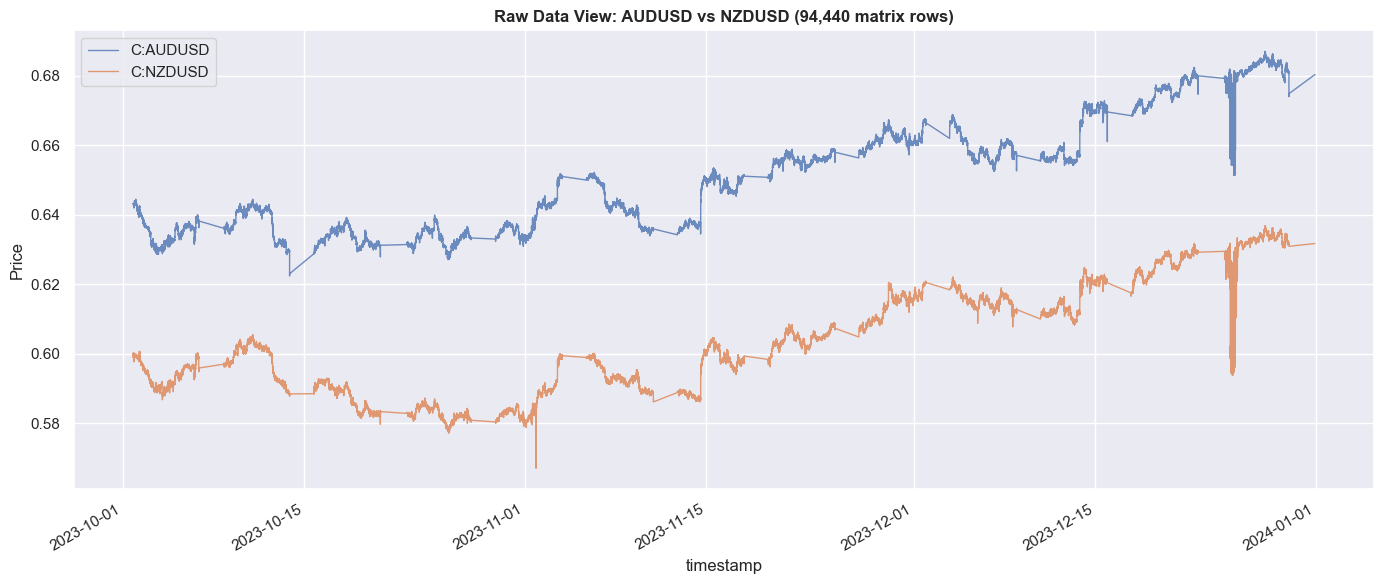

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to Bluegrey Infrastructure
sys.path.append(os.path.abspath('../..'))
from src.store import

print("🗄️ Inspecting DataStore 'fx.min' Matrices...")
store = DataStore(library_name="fx.min")

# 2. Use a massive date window to pull ALL available data
start_date = "2023-10-01"
end_date = "2024-01-01"
assets = ['C:AUDUSD', 'C:NZDUSD']

# Load both assets at once (returns a dict of matrices)
matrices = store.load(assets, start_date=start_date, end_date=end_date)

if matrices and 'close' in matrices:
    # Extract the "close" matrix (Index=Time, Columns=Assets)
    close_matrix = matrices['close']
    
    if not close_matrix.empty:
        row_count = len(close_matrix)
        first_date = close_matrix.index.min()
        last_date = close_matrix.index.max()
        
        print(f"\n✅ Data Matrix Assembled Successfully!")
        print(f"   Total Time Steps: {row_count:,}")
        print(f"   Date Range:       {first_date}  -->  {last_date}")
        
        # 3. Inspect individual assets within the matrix
        for asset in assets:
            if asset in close_matrix.columns:
                # Count non-NaN values to see if an asset has missing data
                valid_ticks = close_matrix[asset].count()
                print(f"   {asset} valid ticks: {valid_ticks:,}")
        
        # 4. Plot the raw data paths
        sns.set_theme(style="darkgrid")
        plt.figure(figsize=(14, 6))
        
        # We can just call plot on the DataFrame directly now!
        close_matrix.plot(ax=plt.gca(), linewidth=1, alpha=0.8)
        
        plt.title(f"Raw Data View: AUDUSD vs NZDUSD ({row_count:,} matrix rows)", fontsize=12, fontweight='bold')
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()
    else:
        print("❌ The 'close' matrix is empty. No dates matched.")
else:
    print("❌ DATABASE EMPTY: load() returned no valid matrices.")

🗄️ Loading 1m Matrices from Librarian...
✅ Loaded Raw Matrix: 92,979 1-minute bars.
⏳ Resampling to 15-Minute Structural Timeframe...
✅ Resampled Matrix: 6,204 15-minute bars.
🧠 Computing M15 Dynamic Cointegration Vectors...
⚙️ Executing M15 Turnover-Aware Matrix Simulation...

📊 --- QUICK PORTFOLIO RESULTS: Kalman Filter - AUD-NZD (M15 Structural) ---
   Frictionless Return: 0.02%
   Net Strategy Return: -10.05% (EW Benchmark: 0.14%)
   Max Drawdown:        -10.19%
   Win Rate (Bars):     12.4%
   Total Fees Paid:     $10,072.22
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: C:\Users\7325\Documents\Bluegrey\research\Tearsheets\Kalman_Filter_-_AUD-NZD_(M15_Structural)_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


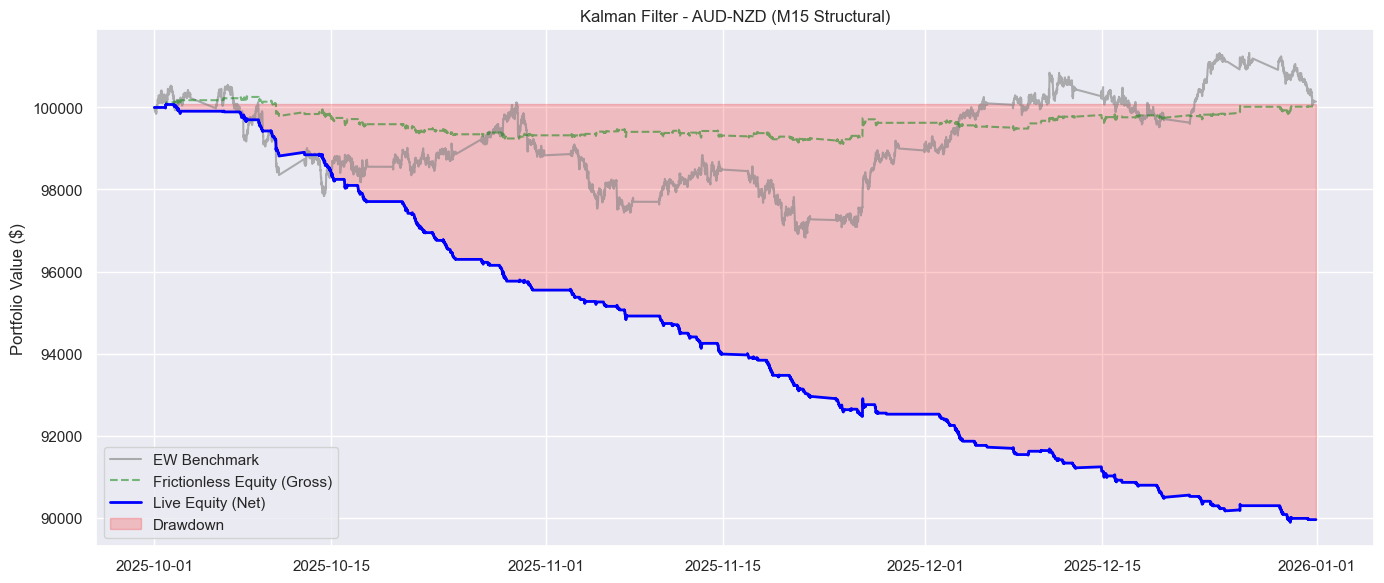

In [ ]:
import sys
import os
import pandas as pd
import warnings

# 1. Connect to Bluegrey Infrastructure
sys.path.append(os.path.abspath('../..'))
from src.store importStore
from src.vector_backtester import PortfolioVectorEngine
from strategies.kalman_pairs import KalmanPairsStrategy

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# 2. Load the Atomic 1-Minute Multi-Asset Matrix
print("🗄️ Loading 1m Matrices from Librarian...")
store = DataStore(library_name="fx.min")

leg_y = 'C:AUDUSD'
leg_x = 'C:NZDUSD'

matrices = store.load([leg_y, leg_x], start_date="2025-10-01", end_date="2026-01-01")

if matrices and 'close' in matrices and not matrices['close'].empty:
    raw_prices_matrix = matrices['close']
    print(f"✅ Loaded Raw Matrix: {raw_prices_matrix.shape[0]:,} 1-minute bars.")

    # ---------------------------------------------------------
    # 2.5 INSTITUTIONAL DOWNSAMPLING (The M15 Edge)
    # ---------------------------------------------------------
    print("⏳ Resampling to 15-Minute Structural Timeframe...")
    # '15min' or '15T' groups the index into 15-minute buckets.
    # .last() takes the final closing price of that 15-minute window.
    prices_matrix_15m = raw_prices_matrix.resample('15min').last().dropna()
    
    print(f"✅ Resampled Matrix: {prices_matrix_15m.shape[0]:,} 15-minute bars.")

    # 3. Strategy Instantiation (Adjusted for M15)
    params = {
        'leg_y': leg_y,
        'leg_x': leg_x,
        'entry_z': 2.5,      # Increased: We only want severe structural dislocations
        'exit_z': 0.5,       # Exit before mean (0.0) to avoid getting chopped by noise
        'z_lookback': 48,    # 48 bars * 15m = 12 Hours rolling window for Z-Score
        'delta': 1e-5,       # Keep adaptation rate steady
        'vt': 1e-3
    }
    
    strategy = KalmanPairsStrategy(instruments={leg_y: None, leg_x: None}, params=params)
    print("🧠 Computing M15 Dynamic Cointegration Vectors...")
    
    # Adapter for strategy expectations
    adapter_df = prices_matrix_15m.copy()
    adapter_df.columns = [f"{col}_close" for col in adapter_df.columns]
    
    signals_matrix_15m = strategy.generate_signals(adapter_df)
    
    # 4. Igniting the Portfolio Engine
    print("⚙️ Executing M15 Turnover-Aware Matrix Simulation...")
    engine = PortfolioVectorEngine(
        prices=prices_matrix_15m, 
        signals=signals_matrix_15m, 
        asset_class='FX', 
        initial_capital=100000.0,
        execution_delay=1  # 1-bar delay to prevent look-ahead
    )
    
    stats = engine.run()
    engine.tearsheet(title="Kalman Filter - AUD-NZD (M15 Structural)")

else:
    print("❌ Critical: Could not load valid matrices for backtest.")

🗄️ Loading Matrices from Librarian...
⏳ Resampling to 5-Minute (M5) Timeframe...
⚙️ Running Grid Search: 25 iterations...
✅ Grid Search Complete.


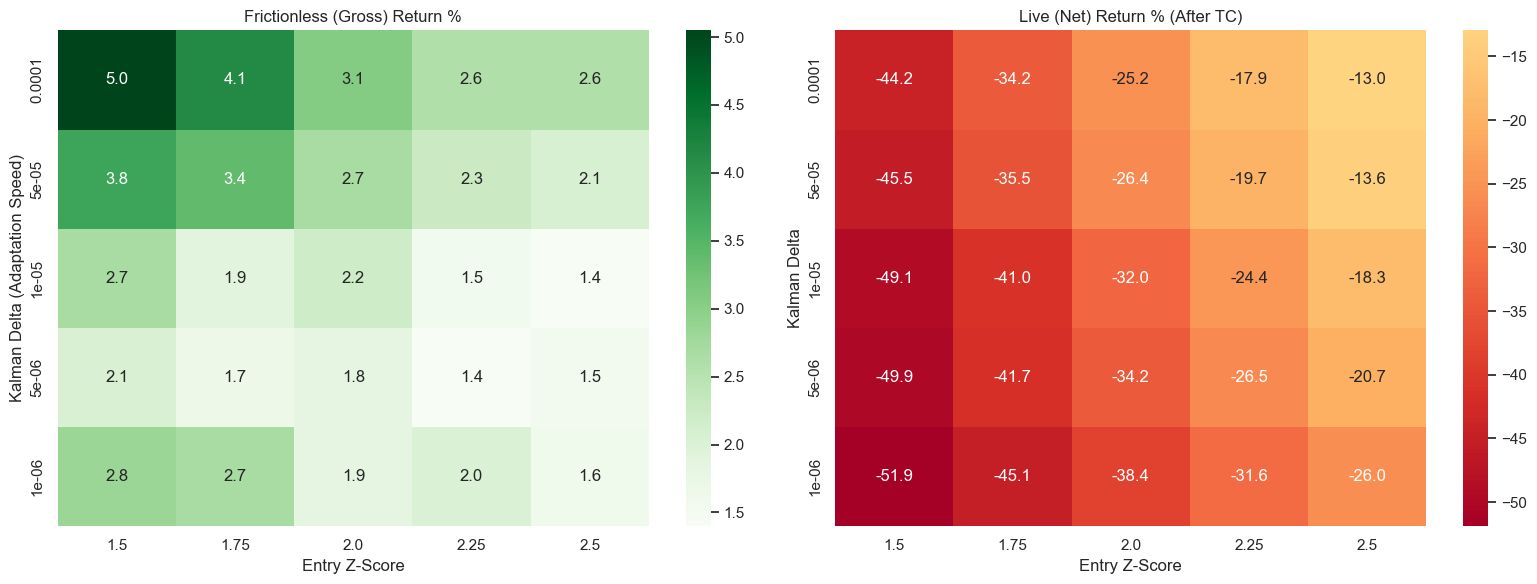

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# 1. Connect to Bluegrey Infrastructure
sys.path.append(os.path.abspath('../..'))
from src.store importStore
from src.vector_backtester import PortfolioVectorEngine
from strategies.kalman_pairs import KalmanPairsStrategy

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# 2. Load the Atomic Data
print("🗄️ Loading Matrices from Librarian...")
store = DataStore(library_name="fx.min")
leg_y, leg_x = 'C:AUDUSD', 'C:NZDUSD'

matrices = store.load([leg_y, leg_x], start_date="2025-10-01", end_date="2026-01-01")
raw_prices_matrix = matrices['close']

# Try an intermediate timeframe: 5-Minute Bars (M5)
# This retains enough volatility to trigger signals, but reduces M1 hyper-churn.
print("⏳ Resampling to 5-Minute (M5) Timeframe...")
prices_matrix_m5 = raw_prices_matrix.resample('5min').last().dropna()

adapter_df = prices_matrix_m5.copy()
adapter_df.columns = [f"{col}_close" for col in adapter_df.columns]

# 3. Define the Grid Search Space
# We sweep Delta (Adaptation speed) vs Entry Z-Score
deltas = [1e-4, 5e-5, 1e-5, 5e-6, 1e-6] 
entry_zs = [1.5, 1.75, 2.0, 2.25, 2.5]
z_lookback = 100 # Approx 8 hours of M5 bars

results = np.zeros((len(deltas), len(entry_zs)))
gross_results = np.zeros((len(deltas), len(entry_zs)))

print(f"⚙️ Running Grid Search: {len(deltas) * len(entry_zs)} iterations...")

# 4. The Parameter Sweep Loop
for i, delta in enumerate(deltas):
    for j, z in enumerate(entry_zs):
        
        params = {
            'leg_y': leg_y,
            'leg_x': leg_x,
            'entry_z': z,
            'exit_z': 0.0,
            'z_lookback': z_lookback,
            'delta': delta,
            'vt': 1e-3
        }
        
        strategy = KalmanPairsStrategy(instruments={leg_y: None, leg_x: None}, params=params)
        signals = strategy.generate_signals(adapter_df)
        
        engine = PortfolioVectorEngine(
            prices=prices_matrix_m5, 
            signals=signals, 
            asset_class='FX', 
            initial_capital=100000.0,
            execution_delay=1 
        )
        
        stats = engine.run()
        
        # Calculate final Net and Gross Return %
        net_ret = (stats['net_equity'].iloc[-1] / 100000.0 - 1) * 100
        gross_ret = (stats['gross_equity'].iloc[-1] / 100000.0 - 1) * 100
        
        results[i, j] = net_ret
        gross_results[i, j] = gross_ret

print("✅ Grid Search Complete.")

# 5. Plot the Alpha Surface Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(gross_results, annot=True, fmt=".1f", xticklabels=entry_zs, yticklabels=deltas, cmap="Greens", ax=ax1)
ax1.set_title("Frictionless (Gross) Return %")
ax1.set_xlabel("Entry Z-Score")
ax1.set_ylabel("Kalman Delta (Adaptation Speed)")

sns.heatmap(results, annot=True, fmt=".1f", xticklabels=entry_zs, yticklabels=deltas, cmap="RdYlGn", center=0, ax=ax2)
ax2.set_title("Live (Net) Return % (After TC)")
ax2.set_xlabel("Entry Z-Score")
ax2.set_ylabel("Kalman Delta")

plt.tight_layout()
plt.show()